# Kinostatistiken in Österreich

In diesem Notebook werden unterschiedlichste Statistekn zum Thema Kino und Film in Österreich gezeigt und auf kreative Weise verglichen um neue Erkenntnise über das Thema zu liefern.

# Vorbereitungen

Bevor mit den Versuchen gestartet werden kann, müssen zuerste die jeweiligen Daten so wie entsprechende Python Libaries importiert werden, um die Menge an Daten bestmöglich zu verarbeiten und dar zu stellen.

## Import derr Libraries

Um die Datenmenge bestmöglich zu vearbeiten zu können, werden folgende Libraries importiert:

In [1]:
!pip install geopandas

Defaulting to user installation because normal site-packages is not writeable


In [2]:
#Import von Pandas
import pandas as pd
#Import von Seaborn
import seaborn as sns
#Import von Matplotlib
import matplotlib.pyplot as plt
#Import von NumPY
import numpy as np
#Import von Plotly.express
import plotly.express as px
import geopandas as gpd

Diese Bibliotheken sind wichtig für die Verarbeitung von Big Data, da sie effiziente Datenstrukturen, leistungsstarke Analysetools und skalierbare Visualisierungsmöglichkeiten bieten, um große Datenmengen zu handhaben und aussagekräftige Erkenntnisse zu gewinnen.

Eine kurze Erklärung, wofür die importierten Libraries notwendig sind:

Pandas: Wird verwendet, um Daten in tabellarischer Form zu organisieren und zu analysieren. Es bietet Datenstrukturen und Funktionen, um Daten effizient zu manipulieren und zu bearbeiten.

Seaborn: Eine Datenvisualisierungs-Bibliothek, die auf Matplotlib aufbaut und eine einfachere Syntax für die Erstellung ästhetisch ansprechender statistischer Grafiken bietet.

Matplotlib.pyplot: Eine umfassende Visualisierungsbibliothek für Python. Sie ermöglicht die Erstellung verschiedener Arten von Diagrammen, Plots und visuellen Darstellungen von Daten.

Numpy: Wird verwendet, um effiziente multidimensionale Array-Operationen durchzuführen, insbesondere für numerische Berechnungen und Datenverarbeitung in Python.

Plotly.express: Eine Bibliothek zur einfachen Erstellung interaktiver und ansprechender Visualisierungen. Plotly Express bietet eine hohe Abstraktionsebene und ermöglicht die schnelle Erstellung von Diagrammen und interaktiven Dashboards.

# Import der Daten

Um Analysen der Statistien durchzuführen werden natürlich auch entsprechende Statistiken benötigt.

Damit die Arbeitsmappe mit pandas eingelesen werden kann, muss diese zuerst in Excel von einer OpenDocument Spreadsheet-Datei (ODS) in eine Excel Arbeitsmappe konvertiert werden.

In [9]:
# Pfad zur Excel-Datei angeben
excel_file = 'Kino_Filme_2019.xlsx'

# Lade alle Tabs der Excel-Datei in ein Dictionary von DataFrames
excel_data = pd.read_excel(excel_file, sheet_name=None)

# Dictionary für die einzelnen bereinigten DataFrames erstellen
cleaned_sheets_dict = {}

# Durchlaufe alle Tabs im Dictionary und bereinige die Daten
for sheet_name, df in excel_data.items():
    # Entferne Zeilen mit NaN-Werten im aktuellen DataFrame
    cleaned_df = df.dropna()
    # Speichere den bereinigten DataFrame im neuen Dictionary
    cleaned_sheets_dict[sheet_name] = cleaned_df
    
# Nun kann auf die bereinigten DataFrames über ihre Variablennamen im cleaned_sheets_dict zugegriffen werden
df_struktur = cleaned_sheets_dict['Tabelle_K1']
df_säle = cleaned_sheets_dict['Tabelle_K2']
df_plätze = cleaned_sheets_dict['Tabelle_K3']
df_besuche = cleaned_sheets_dict['Tabelle_K4']
df_nettoIn = cleaned_sheets_dict['Tabelle_K5']
df_erstAuf = cleaned_sheets_dict['Tabelle_K6']
df_marktTeil = cleaned_sheets_dict['Tabelle_K7']
df_erfolgInterNat = cleaned_sheets_dict['Tabelle_K8']
df_meistÖFilm = cleaned_sheets_dict['Tabelle_K9']

# Zeige den Inhalt der bereinigten DataFrames an

print(df_besuche.head())

  K4.  Kinobesuche nach Bundesländern 1975 bis 2019     Unnamed: 1  \
1                                             Jahr   Öster-\nreich   
3                                              1975       20813439   
4                                              1980       17533899   
5                                              1985       13134533   
6                                              1990       10149373   

      Unnamed: 2 Unnamed: 3           Unnamed: 4         Unnamed: 5  \
1  Burgen-\nland    Kärnten  Nieder-\nösterreich  Ober-\nösterreich   
3         612648    1244730              3194377            2646972   
4         435423    1021946              2310608            2432015   
5         243580     666610              1713762            1678975   
6         154864     544943              1050042            1269420   

  Unnamed: 6     Unnamed: 7 Unnamed: 8     Unnamed: 9 Unnamed: 10  
1   Salzburg  Steier-\nmark      Tirol  Vorarl-\nberg        Wien  
3    1365138    

Die NaN Daten wurden entfernt, allerdings sind die Tabellennamen nicht optimal, um mit ihnen zu Arbeiten.
Daher werden die Namen der Datensätzte für die Bundesländer ausgebessert

In [10]:
# Neue Spaltennamen definieren
neue_spaltennamen = {
    "Unnamed: 1": "Österreich",
    "Unnamed: 2": "Burgenland",
    "Unnamed: 3": "Kärnten",
    "Unnamed: 4": "Niederösterreich",
    "Unnamed: 5": "Oberösterreich",
    "Unnamed: 6": "Salzburg",
    "Unnamed: 7": "Steiermark",
    "Unnamed: 8": "Tirol",
    "Unnamed: 9": "Vorarlberg",
    "Unnamed: 10": "Wien"
}

# Umbenennen der Spalten in den notwendigen Datensätzen
df_säle = df_säle.rename(columns=neue_spaltennamen)
df_besuche = df_besuche.rename(columns=neue_spaltennamen)
df_struktur = df_struktur.rename(columns=neue_spaltennamen)
df_plätze = df_plätze.rename(columns=neue_spaltennamen)
df_nettoIn = df_nettoIn.rename(columns=neue_spaltennamen)

# Neuer Name für die spezifische Spalte
neuer_spaltenname = "Jahr"

# Umbenennen der spezifischen Spalte in df_plätze
df_säle = df_säle.rename(columns={"K2.  Kinosäle nach Bundesländern 1975 bis 2019": neuer_spaltenname})
df_besuche = df_besuche.rename(columns={"K4.  Kinobesuche nach Bundesländern 1975 bis 2019": neuer_spaltenname})
df_plätze = df_plätze.rename(columns={"K3.  Sitzplatzkapazität der Kinos nach Bundesländern 1975 bis 2019": neuer_spaltenname})
df_nettoIn = df_nettoIn.rename(columns={"K5.  Nettoeinnahmen der Kinos nach Bundesländern 1985 bis 2019": neuer_spaltenname})

# Neuer Name für die spezifische Spalte
neuer_spaltenname_gliederung = "Gliederung"
df_struktur = df_struktur.rename(columns={"K1.  Struktur der Kinos (Anzahl der Säle, Sitzplatzkapazität, Bespielung) 2019 nach Bundesländern": neuer_spaltenname_gliederung}) 

print(df_besuche.head())


    Jahr     Österreich     Burgenland  Kärnten     Niederösterreich  \
1  Jahr   Öster-\nreich  Burgen-\nland  Kärnten  Nieder-\nösterreich   
3   1975       20813439         612648  1244730              3194377   
4   1980       17533899         435423  1021946              2310608   
5   1985       13134533         243580   666610              1713762   
6   1990       10149373         154864   544943              1050042   

      Oberösterreich  Salzburg     Steiermark    Tirol     Vorarlberg     Wien  
1  Ober-\nösterreich  Salzburg  Steier-\nmark    Tirol  Vorarl-\nberg     Wien  
3            2646972   1365138        2412985  1681272         454036  7201281  
4            2432015   1059825        2103563  1543016         583071  6044432  
5            1678975    865275        1073541  1147734         450000  5295056  
6            1269420    704673        1024752   819839         330110  4250730  


Zu letzt wird noch die erste Zeile entfernt der Daten entfert, da andernfalls der erste Wert der Name eines Bundeslandes ist und somit die Grafiken fehlerhaft wären.

In [6]:
print(df_besuche.head())

    Jahr     Österreich     Burgenland  Kärnten     Niederösterreich  \
1  Jahr   Öster-\nreich  Burgen-\nland  Kärnten  Nieder-\nösterreich   
3   1975       20813439         612648  1244730              3194377   
4   1980       17533899         435423  1021946              2310608   
5   1985       13134533         243580   666610              1713762   
6   1990       10149373         154864   544943              1050042   

      Oberösterreich  Salzburg     Steiermark    Tirol     Vorarlberg     Wien  
1  Ober-\nösterreich  Salzburg  Steier-\nmark    Tirol  Vorarl-\nberg     Wien  
3            2646972   1365138        2412985  1681272         454036  7201281  
4            2432015   1059825        2103563  1543016         583071  6044432  
5            1678975    865275        1073541  1147734         450000  5295056  
6            1269420    704673        1024752   819839         330110  4250730  


In [7]:
df_plätze= df_plätze.iloc[1:]  # Erste Zeile entfernen
df_säle= df_säle.iloc[1:]  # Erste Zeile entfernen
df_nettoIn= df_nettoIn.iloc[1:]
df_besuche= df_besuche.iloc[1:]
# Abfrage der Zeilennamen
zeilennamen = df_säle


# Ausgabe der Zeilennamen
print(df_besuche.head())

   Jahr Österreich Burgenland  Kärnten Niederösterreich Oberösterreich  \
3  1975   20813439     612648  1244730          3194377        2646972   
4  1980   17533899     435423  1021946          2310608        2432015   
5  1985   13134533     243580   666610          1713762        1678975   
6  1990   10149373     154864   544943          1050042        1269420   
7  1995   11922939     225336   539589          2018631        1468975   

  Salzburg Steiermark    Tirol Vorarlberg     Wien  
3  1365138    2412985  1681272     454036  7201281  
4  1059825    2103563  1543016     583071  6044432  
5   865275    1073541  1147734     450000  5295056  
6   704673    1024752   819839     330110  4250730  
7   744250    1261519   938261     348839  4377539  


Die Daten wurden nun optimal für die Verarbeitung vorbereitet. NaN-Werte wurden entfernt und die Zeilen sind richtig bennant, so dass mit ihnen einfacher gearbeitet werden kann.

# Analyse

## Sitzplatzkapazität und Anzahl der Kinosäle 

Als erstes wird eine Grafik erstellt, die den zeitlichen Vergleich zwischen der Sitzplatzkapazität und der Anzahl der Kinosäle darstellt, 
um mögliche Zusammenhänge oder Trends visuell zu erfassen.

Eine kurze Erklärung, was in diesem Codeabschnitt passiert:

1.Datenextraktion:
jahre_kapazität und sitzplatzkapazität werden aus dem DataFrame df_plätze extrahiert. Diese Listen enthalten die Jahre und die entsprechende Sitzplatzkapazität in Österreich.
jahre_säle und kinosäle werden aus dem DataFrame df_säle extrahiert. Diese Listen enthalten die Jahre und die Anzahl der Kinosäle.

2.Grafische Darstellung:
    fig, ax1 = plt.subplots(figsize=(12, 6)): Es wird eine neue Abbildung mit einer einzelnen Achse erstellt, die für die Visualisierung der Daten verwendet wird.
    ax1.plot(jahre_kapazität, sitzplatzkapazität, color=color, label='Sitzplatzkapazität'): Ein Linienplot wird für die Sitzplatzkapazität über den Jahren erstellt und auf der ersten y-Achse (ax1) dargestellt.
    ax2 = ax1.twinx(): Es wird eine zweite y-Achse erstellt, um die Anzahl der Kinosäle zu visualisieren.
    ax2.plot(jahre_säle, kinosäle, color=color, label='Anzahl Kinosäle'): Ein weiterer Linienplot für die Anzahl der Kinosäle über den Jahren wird auf der zweiten y-Achse (ax2) dargestellt.

3.Anpassungen und Darstellung der Grafik:
    fig.tight_layout(): Sorgt für eine bessere Anpassung der Subplots innerhalb der Abbildung.
    fig.legend(loc="upper right"): Fügt eine Legende zur Abbildung hinzu, um die Linien zu erklären.
    plt.title('Zeitlicher Vergleich von Sitzplatzkapazität und Anzahl der Kinosäle'): Setzt den Titel der Grafik.
    plt.xticks(jahre_kapazität[::tick_step], rotation=45): Setzt die x-Ticks auf der Basis der Jahre, wobei nur jeden tick_step-ten Eintrag angezeigt wird.

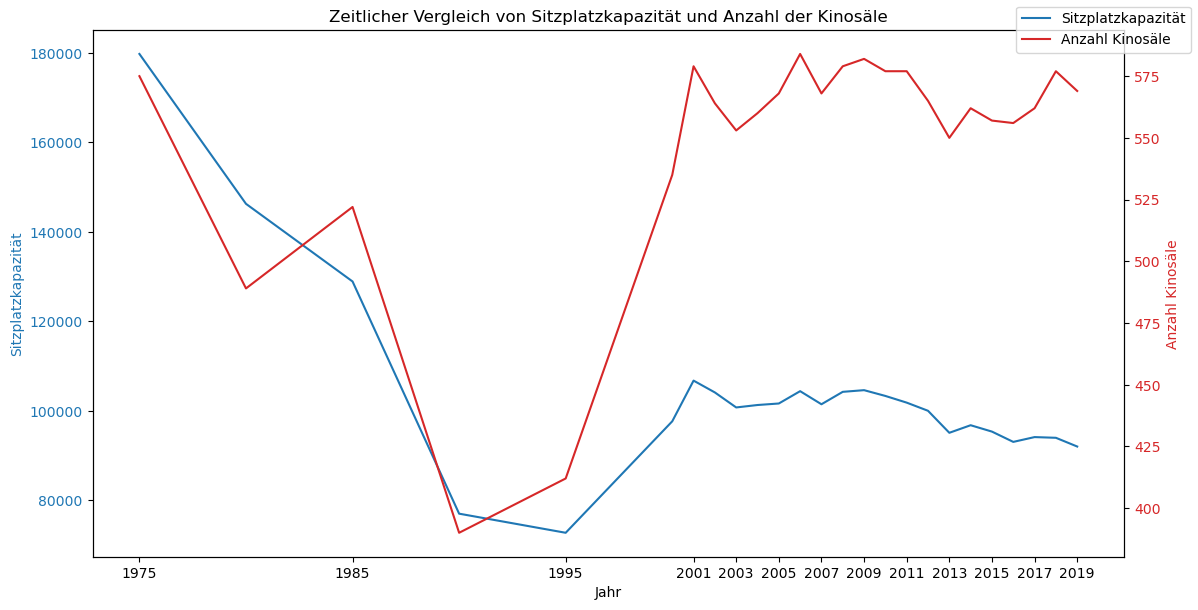

In [8]:
# Daten für die Sitzplatzkapazität und Anzahl der Kinosäle extrahieren
jahre_kapazität = df_plätze['Jahr'].tolist()
sitzplatzkapazität = df_plätze['Österreich'].tolist()

jahre_säle = df_säle['Jahr'].tolist()
kinosäle = df_säle['Österreich'].tolist()

# Zeitlicher Vergleich von Sitzplatzkapazität und Anzahl der Kinosäle
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot für Sitzplatzkapazität auf Achse 1
color = 'tab:blue'
ax1.set_xlabel('Jahr')
ax1.set_ylabel('Sitzplatzkapazität', color=color)
ax1.plot(jahre_kapazität, sitzplatzkapazität, color=color, label='Sitzplatzkapazität')
ax1.tick_params(axis='y', labelcolor=color)

# Zweite y-Achse für Anzahl der Kinosäle
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Anzahl Kinosäle', color=color)
ax2.plot(jahre_säle, kinosäle, color=color, label='Anzahl Kinosäle')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
fig.legend(loc="upper right")
plt.title('Zeitlicher Vergleich von Sitzplatzkapazität und Anzahl der Kinosäle')

# Setze die Anzeige der x-Ticks
tick_step = 2  # Schritte zwischen den angezeigten Ticks
plt.xticks(jahre_kapazität[::tick_step], rotation=45)  # Nur jeden `tick_step`-ten Eintrag anzeigen

plt.show()

# Angenommen, Sie haben bereits die richtigen Spalten für die Jahre extrahiert
jahre_säle = df_säle['Jahr']
jahre_kapazität = df_plätze['Jahr']

# Erstellen eines neuen DataFrames mit den Jahren und den jeweiligen Daten
df_jahre = pd.DataFrame({'Jahr': jahre_kapazität, 'Anzahl_Säle': jahre_säle, 'Sitzplatzkapazität': sitzplatzkapazität})

Es lässt sich anhand der Grafik deutlich erkennen, dass über die Jahre die Sitzplatzkapazität sehr abgenommen hatt, während die Anzahl der Kinosäle gestiegen ist.
Draus lässt sich die Vermutung aufstellen, dass die einzlenen Sitzplätze größer geworden sind und Komfort bgeonnen hat, einen größere Rolle zu spielen.

## Verteilung der Sitzplatzkapazität nach Anzahl der Säle

Die Heatmap ermöglicht eine visuelle Analyse der Sitzplatzkapazität in Bezug auf die Anzahl der Säle über die verschiedenen Jahre hinweg. Durch die Farbskala können Muster oder Trends identifiziert werden, zum Beispiel ob es eine Korrelation zwischen der Anzahl der Säle und der Sitzplatzkapazität gibt oder ob bestimmte Jahre besonders hohe oder niedrige Kapazitäten aufweisen.

Eine erklärung des Codes:

1.Datenverarbeitung:
        heatmap_data = df_jahre.pivot(index='Jahr', columns='Anzahl_Säle', values='Sitzplatzkapazität'): Hier wird ein Pivot der Daten durchgeführt, um eine Tabelle zu erstellen, die die Sitzplatzkapazität basierend auf den Jahren (Index) und der Anzahl der Säle (Spalten) zeigt. Die Werte in der Tabelle sind die entsprechenden Sitzplatzkapazitäten.

2.Grafische Darstellung als Heatmap:
        plt.figure(figsize=(10, 8)): Es wird eine neue Abbildung mit einer bestimmten Größe erstellt, um die Heatmap darauf zu zeichnen.
        sns.heatmap(heatmap_data, cmap='YlGnBu'): Die Heatmap wird mit den Daten aus heatmap_data erstellt und mit der Farbpalette 'YlGnBu' dargestellt. Dabei werden höhere Werte in Grün und niedrigere Werte in Blau dargestellt, wobei Gelb dazwischen liegt.

3.Anpassungen und Darstellung der Grafik:
        plt.title('Verteilung von Sitzplatzkapazität nach Anzahl der Säle über die Jahre'): Setzt den Titel der Grafik, um den Inhalt klar zu beschreiben.
        plt.show(): Zeigt die erstellte Heatmap an.

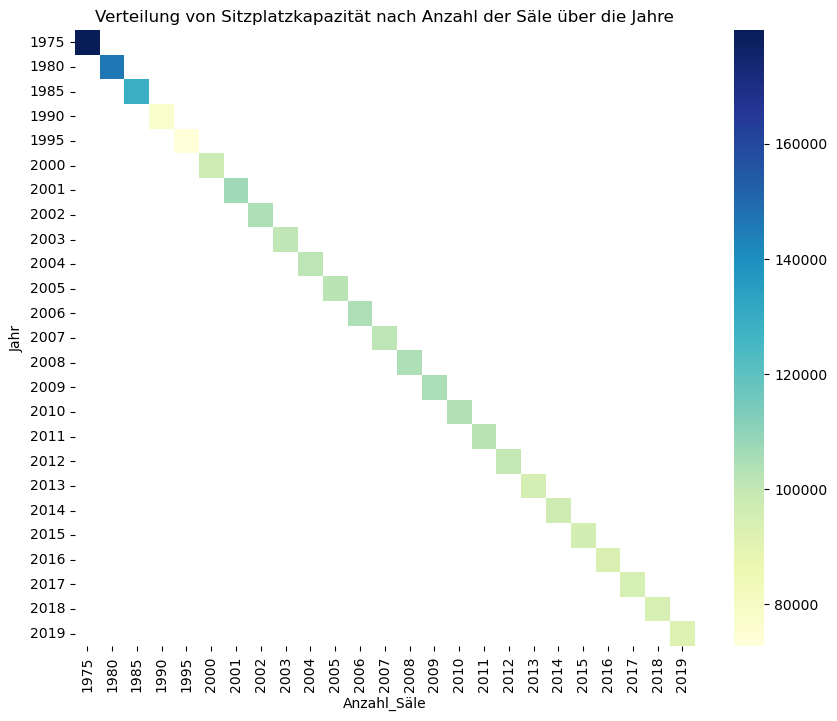

In [8]:
# Heatmap der Sitzplatzkapazität nach Kategorien über die Jahre
heatmap_data = df_jahre.pivot(index='Jahr', columns='Anzahl_Säle', values='Sitzplatzkapazität')
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, cmap='YlGnBu')
plt.title('Verteilung von Sitzplatzkapazität nach Anzahl der Säle über die Jahre')
plt.show()

An dieser Grafik lässt sich sehr gut ablesen, dass die Anzahl der Sitzplätze nach 1975 abgenommen hat und seit dem nicht sehr stark schwankend ist.

# Regionale Unterschiede

Nun sollen regionale Unterschiede untersucht werden.
Dafür werden zwei verschiedene Choroplethenkarten für Österreich erstellt.

Choroplethenkarten sind sehr effektiv, um die Verteilung von Daten über geografische Gebiete hinweg zu zeigen. Sie ermöglichen es, auf einen Blick zu erkennen, wie sich bestimmte Merkmale oder Werte in verschiedenen Regionen entwickeln
In diesem Fall sollen unterschiedliche Regionen gezeigt werden.
Durch die Farbcodierung oder Schattierung von Gebieten entsprechend der Werte der dargestellten Daten können Choroplethenkarten regionale Unterschiede deutlich machen. Dadurch lassen sich Trends oder Muster in den Daten leicht erkennen.

In dem Chunk geschieht folgendes:
Der Code führt zwei verschiedene Choroplethenkarten für Österreich durch, wobei die Farbskalen jeweils unterschiedliche Daten visualisieren.

Anzahl der Kinosäle nach Bundesländern:
Zuerst werden die Daten aus df_struktur mit den Geodaten aus der Shape-Datei BLK200_Lambert.shp gemerged, wobei der Index der Bundesländer als Verbindung dient.
Dann wird eine Choroplethenkarte erstellt, die die Anzahl der Kinosäle pro Bundesland darstellt. Jedes Bundesland wird mit einer Farbe entsprechend seiner Anzahl an Kinosälen eingefärbt, wobei die Farbskala von niedrig (grün) nach hoch (blau) reicht.

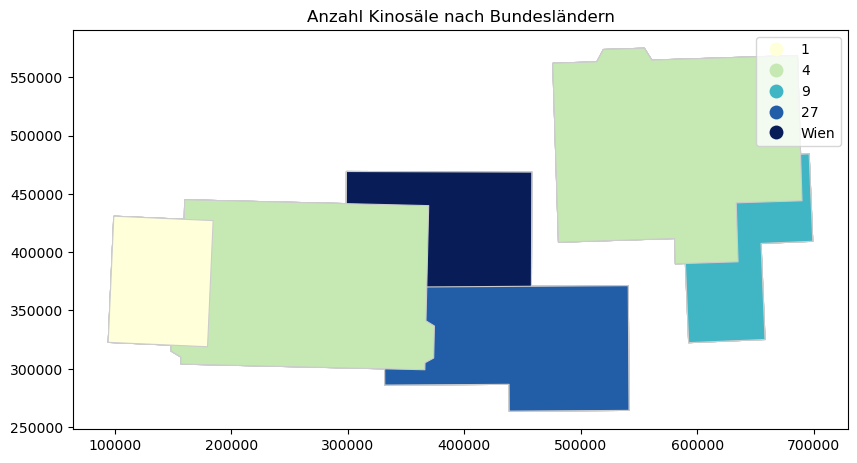

In [16]:
# Annahme: Die Bundesländer sind als Index im DataFrame df_struktur und gdf enthalten
gdf = gpd.read_file('BLK200_Lambert.shp')

# Füge Daten zu Geodaten hinzu (Merge anhand der Indexe)
merged_struktur = gdf.merge(df_struktur, how='left', left_index=True, right_index=True)
merged_besuche = gdf.merge(df_besuche, how='left', left_index=True, right_index=True)


# Definiere die korrekten Spalten für die Anzahl der Kinosäle nach Bundesländern
bundesland_spalten = [
   "Burgenland",
   "Kärnten",
    "Niederösterreich",
    "Oberösterreich",
    "Salzburg",
    "Steiermark",
    "Tirol",
    "Vorarlberg",
    "Wien"
]

# Erstelle Kartenvisualisierung der Kinosäle nach Bundesländern
fig, ax = plt.subplots(figsize=(10, 10))
for spalte in bundesland_spalten:
    merged_struktur.plot(column=spalte, cmap='YlGnBu', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)
plt.title('Anzahl Kinosäle nach Bundesländern')
plt.show()


Nun wird eine zweite choroplethenkarte erstellt. Bei dieser sollen Besuche pro 1000 Einwohner nach Bundesländern dartsellen.

Ähnlich wie zuvor werden die Besucherdaten aus df_besuche mit den Geodaten gemerged.
  Danach wird eine weitere Choroplethenkarte erstellt, die die Besucherzahlen pro 1000 Einwohner in den Bundesländern visualisiert. Hier wird die Farbskala von niedrig (gelb) nach hoch (rot) verwendet, um die Unterschiede in den Besucherzahlen zwischen den Bundesländern darzustellen.

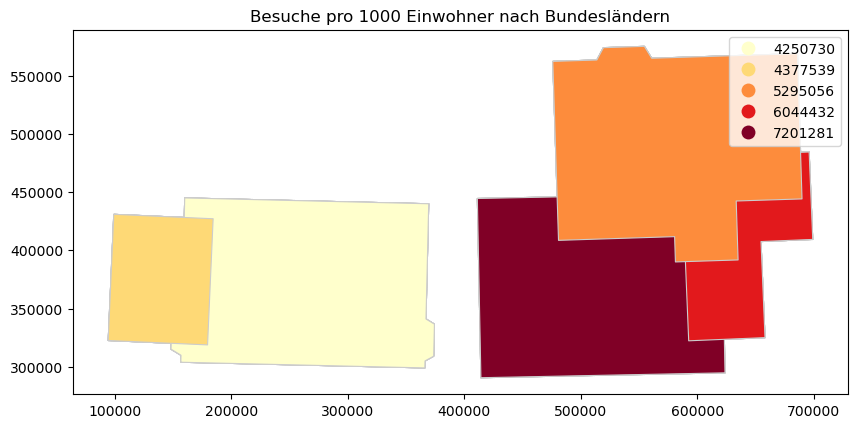

In [15]:
# Choroplethenkarte der Besuchszahlen pro 1000 Einwohner
fig, ax = plt.subplots(figsize=(10, 10))
for spalte in bundesland_spalten:
    merged_besuche.plot(column=spalte, cmap='YlOrRd', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)
plt.title('Besuche pro 1000 Einwohner nach Bundesländern')
plt.show()

Es sollte erkennbar sein, in welchem Bundesland wieviele Kinobesuche getätigt werden anhand der unterschiedlichen Farbschemen.

# Korrelationsmatrix von Kinosälen, Besuchen und Nettoeinnahmen

Als nächstes soll die Korrelation von der Anzahl der Kinosäle, der Besucherzahlen sowie der NEttoeinnahemn für gesamt Österreich dargestellt werden. Dies wird in einer Korrelationsmatrix berrechent, die im Anschluss zur visualisierung in einer Heat Map dargestellt wird.

Eine kurze Erklärugn des folgenden Chunks:

Umbenennen von Spalten: Die Spalten in den DataFrames df_säle, df_besuche und df_nettoIn werden umbenannt, um eine einheitliche Benennung für die Daten zu haben. Die neue Bezeichnung verwendet den Begriff "Österreich" als allgemeine Bezeichnung für die gesamten Daten in den jeweiligen DataFrames.

Merge von DataFrames: Die DataFrames werden basierend auf dem Jahr gemerged, um ein einziges DataFrame namens merged_data zu erstellen, das alle relevanten Daten zu den Kinosälen, den Besuchen und den Nettoeinnahmen enthält.

Berechnung der Korrelationsmatrix: Es wird eine Korrelationsmatrix für die Variablen "Anzahl_Kinosäle", "Besuche" und "Nettoeinnahmen" erstellt. Die Korrelationsmatrix zeigt an, wie stark die lineare Beziehung zwischen diesen Variablen ist. Eine Korrelation nahe bei 1 deutet auf eine starke positive lineare Beziehung hin, während eine Korrelation nahe bei -1 eine starke negative lineare Beziehung anzeigt.

Erstellung einer Heatmap: Basierend auf der Korrelationsmatrix wird eine Heatmap erstellt. In der Heatmap werden die Korrelationskoeffizienten visuell dargestellt, wobei Farben verwendet werden, um die Stärke und Richtung der Korrelation zwischen den Variablen zu zeigen. Die Annotationen in der Heatmap zeigen die genauen Korrelationskoeffizienten an.

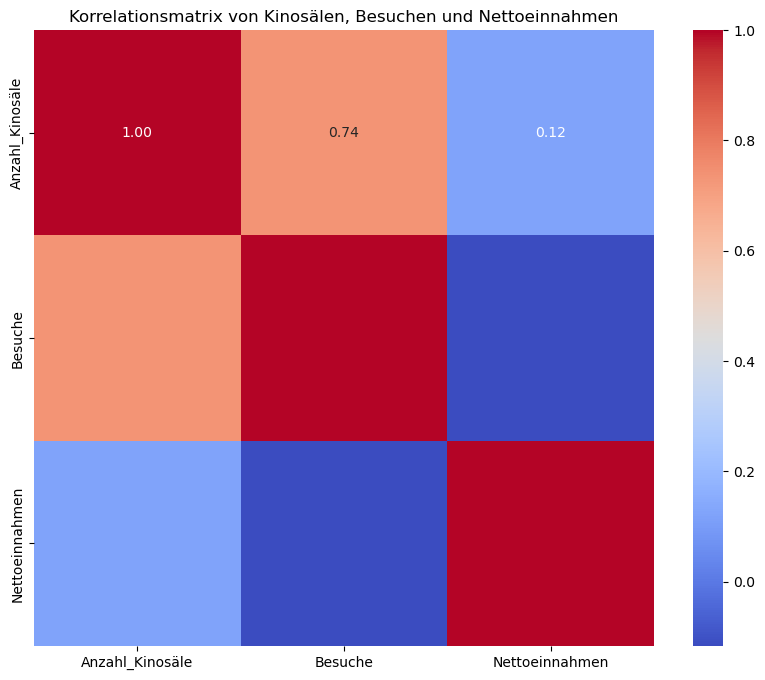

In [12]:
# Neue Spaltennamen definieren als Dictionaries
neue_spaltennamen_säle = {
    "Österreich": "Anzahl_Kinosäle"
}

neue_spaltennamen_besuche = {
    "Österreich": "Besuche"
}

neue_spaltennamen_netto = {
    "Österreich": "Nettoeinnahmen"
}

# Umbenennen der Spalten in den DataFrames
df_säle = df_säle.rename(columns=neue_spaltennamen_säle)
df_besuche = df_besuche.rename(columns=neue_spaltennamen_besuche)
df_nettoIn = df_nettoIn.rename(columns=neue_spaltennamen_netto)


# Merge Daten aus verschiedenen DataFrames basierend auf dem Jahr
merged_data = df_säle.merge(df_besuche, on='Jahr').merge(df_nettoIn, on='Jahr')

# Berechne Korrelationsmatrix
correlation_matrix = merged_data[['Anzahl_Kinosäle', 'Besuche', 'Nettoeinnahmen']].corr()

# Plot Heatmap der Korrelationsmatrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Korrelationsmatrix von Kinosälen, Besuchen und Nettoeinnahmen')
plt.show()


Die generierte Heatmap visualisiert die Korrelationen zwischen den Anzahl_Kinosälen, den Besuchen und den Nettoeinnahmen. Sie ermöglicht es auf einen Blick zu sehen, wie stark diese Variablen miteinander zusammenhängen. Eine positive Korrelation deutet darauf hin, dass eine Zunahme in einer Variable mit einer Zunahme in einer anderen Variable einhergeht, während eine negative Korrelation auf eine abnehmende Beziehung hinweist. Die Stärke der Korrelation wird durch die Intensität der Farben in der Heatmap dargestellt.

# Clusteranalyse der Kinos nach Besuchen und Anzahl Kinosäle.

Es wird eine Clusteranalyse durchgeführt auf grundlage den Daten, die die Anzahl der Kinosäle, die Besucherzahlen und die Nettoeinnahmen enthalten. Die Daten werden in drei Cluster gruppiert, und dann wird ein Scatterplot erstellt, der die Anzahl der Kinosäle gegen die Besucherzahlen darstellt. Die Punkte sind nach den Clustern eingefärbt, wodurch Muster oder Unterschiede zwischen den Kinos deutlich werden können.

Es wird eine Clusteranalyse mit dem KMeans-Algorithmus durchgeführt und die Ergebnisse in einem Scatterplot visualisiert:

Daten für die Clusteranalyse vorbereiten: Die relevanten Spalten für die Clusteranalyse (Anzahl_Kinosäle, Besuche, Nettoeinnahmen) werden aus dem DataFrame merged_data extrahiert und in der Matrix X gespeichert.

KMeans Clustering: Ein KMeans-Modell mit 3 Clustern wird initialisiert und auf den vorbereiteten Daten X trainiert.

Labels zu den Daten hinzufügen: Die Clusterlabels, die durch den KMeans-Algorithmus berechnet wurden, werden dem DataFrame merged_data als neue Spalte mit dem Namen 'Cluster' hinzugefügt.

 Visualisierung der Cluster mit einem Scatterplot: Ein Scatterplot wird erstellt, wobei die x-Achse die Anzahl der Kinosäle (Anzahl_Kinosäle) darstellt, die y-Achse die Besucherzahlen (Besuche) und die Punktfarbe die Clusterzugehörigkeit (Cluster) anzeigt. Die Punkte sind entsprechend der Clusterzugehörigkeit eingefärbt, was es ermöglicht, Muster oder Gruppierungen in den Daten zu erkennen.

Das Ergebnis ist eine visuelle Darstellung der Clusterbildung basierend auf den Merkmalen Anzahl der Kinosäle und Besucherzahlen, die im Titel des Scatterplots erwähnt wird.

C:\ProgramData\Anaconda3\naviagtor\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\ProgramData\Anaconda3\naviagtor\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


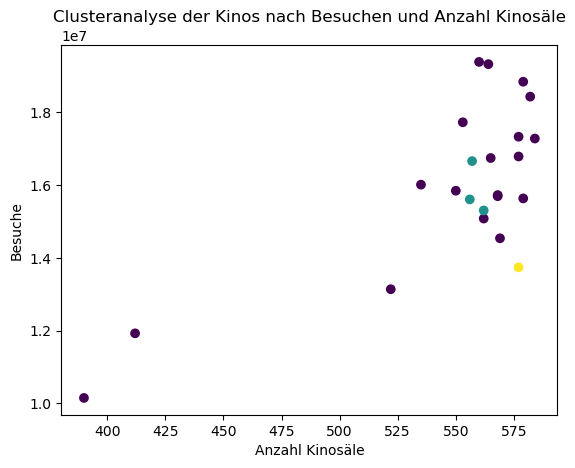

In [13]:
from sklearn.cluster import KMeans


# Daten für Clusteranalyse vorbereiten
X = merged_data[['Anzahl_Kinosäle', 'Besuche', 'Nettoeinnahmen']].values

# KMeans Clustering
kmeans = KMeans(n_clusters=3)
kmeans.fit(X)
merged_data['Cluster'] = kmeans.labels_

# Visualisierung der Cluster mit Scatterplot
plt.scatter(merged_data['Anzahl_Kinosäle'], merged_data['Besuche'], c=merged_data['Cluster'], cmap='viridis')
plt.xlabel('Anzahl Kinosäle')
plt.ylabel('Besuche')
plt.title('Clusteranalyse der Kinos nach Besuchen und Anzahl Kinosäle')
plt.show()


Diese Grafik zeigt, dass es eine Korrelation zwischen der Anzahl der Kinosäle und den Besucherzahlen gibt.

# Analyse des Kinobesuchsverhaltens in Österreich.

### Marktanteile der erstaufgeführten Kinofilme nach Herkunftsländern.


Die vorliegende Darstellung bietet eine anschauliche Analyse der Marktanteile der erstaufgeführten Kinofilme in Österreich für das Jahr 2019, aufgeschlüsselt nach ihren Herkunftsländern. Diese Visualisierung erfolgt in Form eines horizontalen Balkendiagramms, das eine einfache Vergleichbarkeit der Marktanteile ermöglicht. Jeder Balken in der Grafik repräsentiert ein Herkunftsland, wobei die Länge des Balkens direkt proportional zur Anzahl der Besuche in Tausend für Filme aus diesem Land ist. Beispielsweise zeigt ein längerer Balken, dass Filme aus den USA einen höheren Marktanteil haben als Filme aus anderen Ländern.

Der Code für die Erstellung dieser Visualisierung beginnt mit der Erstellung eines horizontalen Balkendiagramms mit Hilfe der matplotlib-Bibliothek. Die Daten werden in einer Liste von Herkunftsländern und den entsprechenden Besuchen in Tausend für jedes Land bereitgestellt. Anschließend werden die Balken entsprechend dieser Daten erzeugt, wobei die y-Achse die Herkunftsländer und die x-Achse die Anzahl der Besuche in Tausend darstellt. Dieses Diagramm ermöglicht es, die Marktanteile der verschiedenen Herkunftsländer auf einen Blick zu erfassen und etwaige Dominanz oder Vielfalt in der Filmproduktion zu erkenne

Detailierte Erklärung des Codes:

1) Datenbereitstellung: Die Liste herkunftsland enthält die Namen der Herkunftsländer, während besuche_in_tausend die entsprechenden Besuche in Tausend für jedes Land enthält.
   2) 
Diagrammerstellung: plt.figure(figsize=(10, 6)) erstellt eine neue Abbildung mit einer Größe von 10x6 Zoll für das Diagramm. plt.barh(herkunftsland, besuche_in_tausend, color='skyblue') erzeugt ein horizontales Balkendiagramm, wobei die y-Achse die Herkunftsländer und die x-Achse die Anzahl der Besuche in Tausend angibt. Die Balken werden entsprechend der Anzahl der Besuche in Tausend für jedes Land erstellt. plt.xlabel('Besuche in Tausend') und plt.ylabel('Herkunftsland') setzen die Beschriftungen für die x- und y-Achsen. plt.title('Marktanteile der erstaufgeführten Kinofilme 2019 nach Herkunftsländern') gibt der Grafik einen Titel. plt.gca().invert_yaxis() invertiert die y-Achse, um die Reihenfolge der Länder umzukehren und die Länder entsprechend ihrer Position von oben nach unten anzuzeigen. plt.show() zeigt das Diagramm an.n.

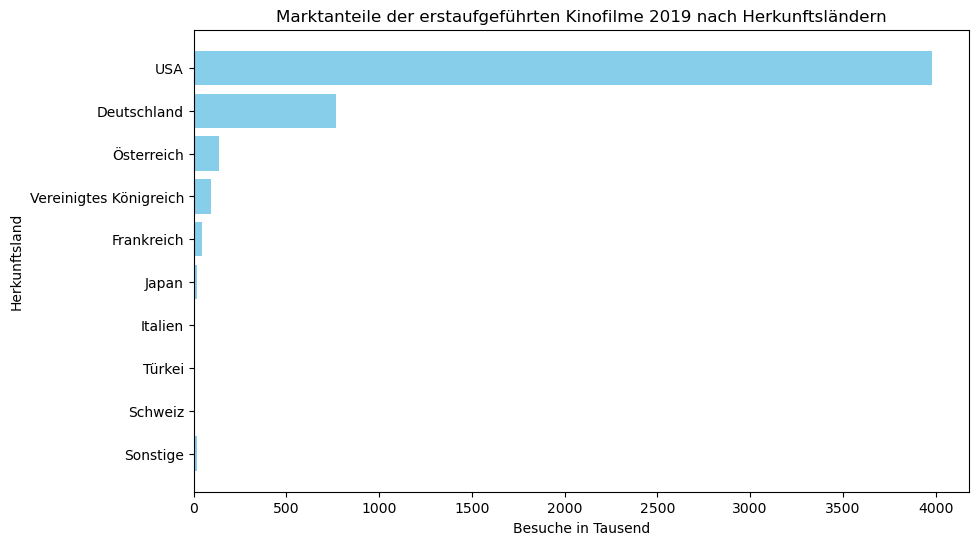

In [2]:
import matplotlib.pyplot as plt

# Daten
herkunftsland = ["USA", "Deutschland", "Österreich", "Vereinigtes Königreich", "Frankreich", "Japan", "Italien", "Türkei", "Schweiz", "Sonstige"]
besuche_in_tausend = [3979.4, 765.8, 137.7, 95.2, 45.9, 18.8, 8.7, 5.7, 4.8, 16.6]

# Diagramm erstellen
plt.figure(figsize=(10, 6))
plt.barh(herkunftsland, besuche_in_tausend, color='skyblue')
plt.xlabel('Besuche in Tausend')
plt.ylabel('Herkunftsland')
plt.title('Marktanteile der erstaufgeführten Kinofilme 2019 nach Herkunftsländern')
plt.gca().invert_yaxis()  # Um die Reihenfolge der Länder umzukehren
plt.show()

### Kinobesuche pro Bundesland (2019).

Die zweite Visualisierung präsentiert die Anzahl der Kinobesuche in Tausend für jedes Bundesland in Österreich im Jahr 2019. Dies erfolgt durch ein vertikales Balkendiagramm, das die Anzahl der Besuche für jedes Bundesland als Balken darstellt. Hierbei dient die Höhe des Balkens als Maß für die Anzahl der Besuche, wodurch ein schneller Vergleich zwischen den Bundesländern ermöglicht wird. So können beispielsweise Bundesländer mit höheren Balken eine höhere Anzahl von Kinobesuchen verzeichnen als solche mit niedrigeren Balken.

Der Code zur Erstellung dieser Visualisierung verwendet ebenfalls die matplotlib-Bibliothek, um ein vertikales Balkendiagramm zu erstellen. Die Daten werden in Form von Listen von Bundesländern und den entsprechenden Kinobesuchen in Tausend für jedes Land bereitgestellt. Die Balken werden entsprechend dieser Daten erzeugt, wobei die x-Achse die Bundesländer und die y-Achse die Anzahl der Besuche in Tausend darstellt. Diese Visualisierung ermöglicht es, Unterschiede im Kinoverhalten der Bevölkerung in verschiedenen Regionen Österreichs zu identifizieren und zu analysiere

Detailierte Erklärung des Codes:

1) Datenbereitstellung: Die Liste bundesland enthält die Namen der Bundesländer, während kinobesuche_in_tausend die entsprechenden Kinobesuche in Tausend für jedes Bundesland enthält.
   2) 
Diagrammerstellung: plt.figure(figsize=(10, 6)) erstellt eine neue Abbildung mit einer Größe von 10x6 Zoll für das Diagramm. plt.bar(bundesland, kinobesuche_in_tausend, color='lightgreen') erzeugt ein vertikales Balkendiagramm, wobei die x-Achse die Bundesländer und die y-Achse die Anzahl der Kinobesuche in Tausend angibt. Die Balken werden entsprechend der Anzahl der Kinobesuche in Tausend für jedes Bundesland erstellt. plt.xlabel('Bundesland') und plt.ylabel('Kinobesuche in Tausend') setzen die Beschriftungen für die x- und y-Achsen. plt.title('Kinobesuche pro Bundesland (2019)') gibt der Grafik einen Titel. plt.xticks(rotation=45) dreht die Beschriftungen der x-Achse um 45 Grad, um sie lesbar zu machen. plt.tight_layout() sorgt für eine optimale Anpassung der Grafik. plt.show() zeigt das Diagramm an.n.n.

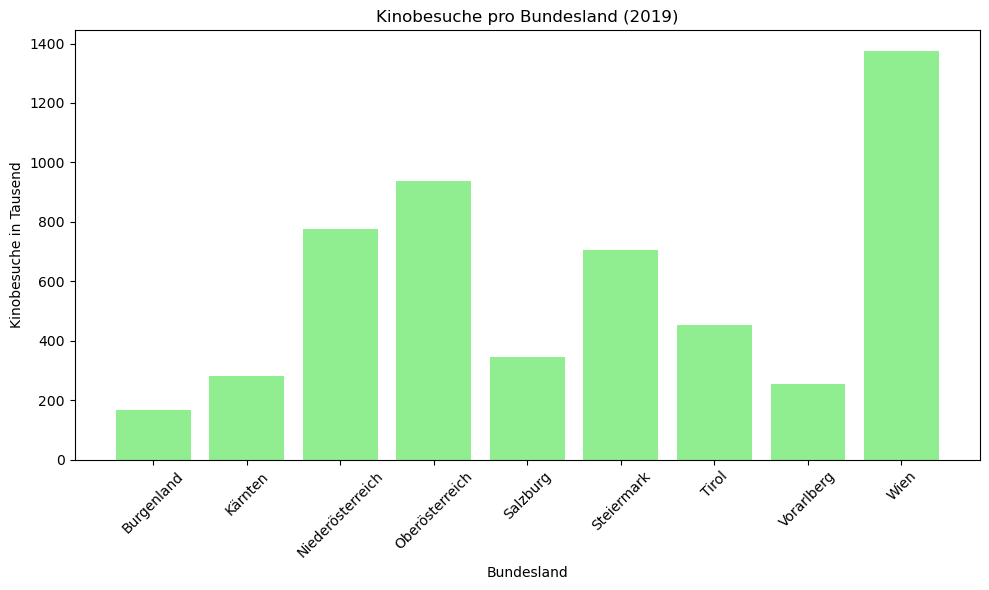

In [1]:
import matplotlib.pyplot as plt

# Daten
bundesland = ["Burgenland", "Kärnten", "Niederösterreich", "Oberösterreich", "Salzburg", "Steiermark", "Tirol", "Vorarlberg", "Wien"]
kinobesuche_in_tausend = [165.1, 279.9, 777.3, 938.4, 345.4, 706.2, 451.8, 255.2, 1375.6]

# Diagramm erstellen
plt.figure(figsize=(10, 6))
plt.bar(bundesland, kinobesuche_in_tausend, color='lightgreen')
plt.xlabel('Bundesland')
plt.ylabel('Kinobesuche in Tausend')
plt.title('Kinobesuche pro Bundesland (2019)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()